<a href="https://colab.research.google.com/github/Matheusbcy/-Data-Science-IA-/blob/main/Machine%20Learning/Projetos/Covid/COVID_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COVID-19 - Kaggle Textos

## Instalação e importação das bibliotecas

In [1]:
import numpy as np
import zipfile
import pandas as pd
import glob
import json
import seaborn as sns
import spacy
import nltk

from IPython.core.display import HTML
from matplotlib import pyplot as plt

In [ ]:
!pip install scispacy

In [3]:
import scispacy

In [ ]:
!pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_md-0.5.4.tar.gz

In [5]:
import en_core_sci_md

In [ ]:
!python -m spacy download en

## Carregamento dos arquivos

In [7]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [8]:
path = "/content/gdrive/MyDrive/Machine Learning/Projetos/COVID-19/CORD-19-research-challenge.zip"

zip_object = zipfile.ZipFile(file = path, mode = "r")

zip_object.extractall("./")
zip_object.close()

## Criação do dataframe com os textos

In [81]:
corona_features = {
    "paper_id": [],
    "title": [],
    "abstract": [],
    "text": []
}

corona_df = pd.DataFrame.from_dict(corona_features)

In [82]:
json_filenames = glob.glob(f'{"./"}//**/*.json', recursive = True)

In [83]:
def return_corona_df(json_filenames, df):
  for file_name in json_filenames:
    row = {
        "paper_id": None,
        "title": None,
        "abstract": None,
        "text": None
    }

    with open(file_name) as json_data:
      if file_name == "./sample_data/anscombe.json":
        continue

      data = json.load(json_data)
      row["paper_id"] = data["paper_id"].strip()
      row["title"] = data["metadata"]["title"].strip()

      abstract_list = [abstract["text"] for abstract in data["abstract"]]
      abstract = "\n".join(abstract_list)
      row["abstract"] = abstract.strip()

      text_list = [text["text"] for text in data["body_text"]]
      text = "\n".join(text_list)
      row["text"] = text.strip()

      df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
  return df

In [84]:
corona_df = return_corona_df(json_filenames, corona_df)

In [85]:
corona_df.shape

(29315, 4)

In [13]:
corona_df.head()

,paper_id,title,abstract,text
0,acd8d28ae75dc1ec5fea2d767e3158545011c1f7,Title: 2 The Role of Interleukin-1 cytokine fa...,"Mycetoma is a neglected tropical disease, ende...",Mycetoma is a chronic granulomatous subcutaneo...
1,2d02192c3d251c2b561d37274350660277658a74,Enabling large-scale genome editing by reducin...,To extend the frontier of genome editing and e...,To achieve similar efficiencies to native Cas9...
2,d8c2466863d8ff87bc1aaf5218ce6f3f7fb29c3b,Social history and exposure to pathogen signal...,Social experiences are an important predictor ...,"The social environment, both in early life and..."
3,c2510fbc213aa74c6c3195cbc8033c7d0f11b248,Deoxynivalenol Promotes Porcine Epidemic Diarr...,Porcine epidemic diarrhea virus (PEDV) is a hi...,the entirety of this autophagic process and is...
4,f3ff1ecae96700f41b83d2a034a3a959428388b0,participated in study design,and chest computed tomographic (CT) images wer...,and clinical features of COVID-19 patients in ...


# Pre-processamento

### Valores faltantes

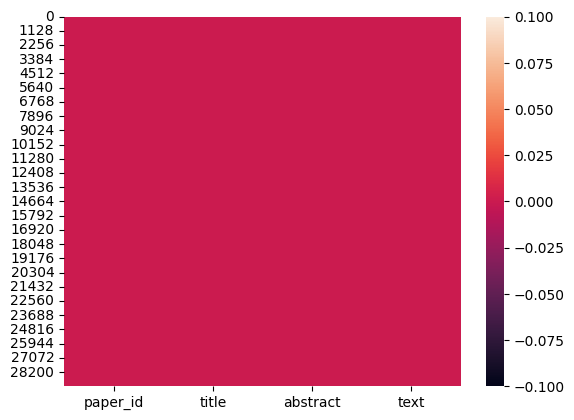

In [15]:
sns.heatmap(corona_df.isnull());

In [17]:
corona_df.shape

(29315, 4)

In [18]:
len(corona_df[corona_df["paper_id"] == ""])

0

In [19]:
len(corona_df[corona_df["title"] == ""])

3583

In [20]:
len(corona_df[corona_df["abstract"] == ""])

8051

In [21]:
len(corona_df[corona_df["text"] == ""])

0

In [86]:
corona_df = corona_df[corona_df["title"] != ""]

In [87]:
corona_df = corona_df[corona_df["abstract"] != ""]

In [88]:
corona_df.shape

(20343, 4)

### Valores duplicados

In [89]:
corona_df.drop_duplicates(["abstract", "text", "title"], inplace = True)

In [90]:
corona_df.shape

(20211, 4)

### Amostra da base de Dados

In [91]:
corona_df = corona_df.sample(n = 500, random_state = 42)

In [92]:
corona_df.shape

(500, 4)

In [93]:
corona_df.head()

,paper_id,title,abstract,text
6205,98e6190d06a8d8774c690be39634a1d64a926dc3,Genetic Diversity and Differentiation at Struc...,Investigating adaptive potential and understan...,Bottlenecked species are prone to genetic drif...
12096,5e87d99a155e3a0d518695c7806b8e2c1409e207,A survey of SNOMED CT implementations,The Systematised Nomenclature of Medicine Clin...,"Countries such as the United States, United Ki..."
25322,b538a13cd3e2f0468a04db032ceb585cad1becd6,Keyword index to volumes 296-307 (2005),A 7-AADKeyword index to volumes 296-307 (2005)...,CD antibody microarray; Cluster of differentia...
2090,b8915fde10e62d4b033a9141910e5639590f0bae,Plant-based solutions for veterinary immunothe...,The opinions expressed and arguments employed ...,The health and well-being of food-bearing anim...
3880,5e3580584a2340a7db087f4115d14f6782e22a36,The burden and clinical manifestation of hospi...,"In tropical Singapore, influenza occurs all ye...",cases were defined as upper respiratory tract ...


In [ ]:
sample_text = corona_df['text'][6205]
sample_text

### Função para pré-processamento

In [94]:
nlp = en_core_sci_md.load(disable = ["parser", "ner"])

nlp.max_length = 2000000

In [34]:
print(spacy.lang.en.stop_words.STOP_WORDS)

{'quite', 'so', 'must', 'this', 'hereafter', 'has', 'back', 'make', 'anyway', 'are', 'namely', 'becomes', 'twelve', 'hereupon', 'mostly', 'alone', 'who', 'until', '’ll', 'whoever', 'and', 'four', 'enough', 'top', 'cannot', 'itself', 'below', 'two', 'both', 'bottom', 'these', "'d", 'may', 'while', 'seems', 'five', 'here', 'what', 'someone', 'us', 'too', 'last', 'been', 'fifteen', 'thus', 'amongst', 'used', 'does', '‘ll', 'amount', 'more', 'n‘t', 'whence', 'wherever', 'up', 'sixty', 'out', 'as', 'another', 'further', 'themselves', 'via', 'can', 'over', 'ten', 'nine', 'do', 'if', 'yourself', '‘ve', 'afterwards', 'hence', 'it', 'yours', '‘d', 'some', 'few', 'than', 'toward', 'various', 'also', 'due', 'something', 'together', 'whereas', "'s", 'front', 'being', 'even', 'then', 'almost', "n't", 'nor', 'in', 'seemed', 'your', 'about', 'name', 'give', 'perhaps', 'everyone', 'not', 'hereby', 'everything', 'throughout', 'move', 'side', 'ever', 'but', 'thereby', 'take', 'please', "'re", 'hundred',

In [35]:
len(spacy.lang.en.stop_words.STOP_WORDS)

326

In [96]:
new_stop_words = ["et", "al", "doi", "-", "copyright", "http", "https", "fig", "table", "result", "now"]

for word in new_stop_words:
  nlp.vocab[word].is_stop = True

In [97]:
def spacy_tokenizer(sentence):
  sentence = sentence.lower()
  list = []
  list = [word.lemma_ for word in nlp(sentence) if not (word.is_stop or word.like_num or word.is_punct or word.is_space or len(word) == 1)]
  list = " ".join([str(element) for element in list])

  return list

In [ ]:
test = sample_text
result = spacy_tokenizer(test)
result

In [98]:
corona_df["text"] = corona_df["text"].apply(spacy_tokenizer)

In [ ]:
print(sample_text)

In [58]:
len(sample_text)

42677

In [60]:
len(corona_df["text"][6205])

27960

## Termos frequentes

In [100]:
for index, row in corona_df.iterrows():
  text_file = open("corpus2/" + row['paper_id'] + '.txt', 'w')
  n = text_file.write(row["text"])
  text_file.close()

In [101]:
from nltk.corpus import PlaintextCorpusReader
corpus = PlaintextCorpusReader("corpus2", ".*")

In [65]:
files = corpus.fileids()

In [ ]:
corpus.raw(files[0])

In [103]:
words = corpus.words()
print(words)

['virus', 'isolate', 'throat', 'swab', 'sample', ...]


In [104]:
len(words)

1431458

In [105]:
frequency = nltk.FreqDist(words)
most_common = frequency.most_common(20)
most_common

[('-', 62470),
 ('.', 22239),
 ('cell', 13584),
 ('/', 9506),
 ('virus', 8910),
 ('al', 8710),
 ('protein', 7708),
 ('study', 7047),
 ('infection', 6904),
 ('show', 4924),
 ('viral', 4488),
 ('1', 3995),
 ('high', 3908),
 ('disease', 3757),
 ('patient', 3700),
 ('result', 3679),
 ('human', 3528),
 ('mouse', 3495),
 ('sequence', 3387),
 ('gene', 3379)]

### Nuvem de palavras

In [74]:
from matplotlib.colors import ListedColormap
color_map = ListedColormap(["orange", "green", "red", "magenta"])

In [77]:
from wordcloud import WordCloud
cloud = WordCloud(background_color = "white", max_words = 100, colormap = color_map)

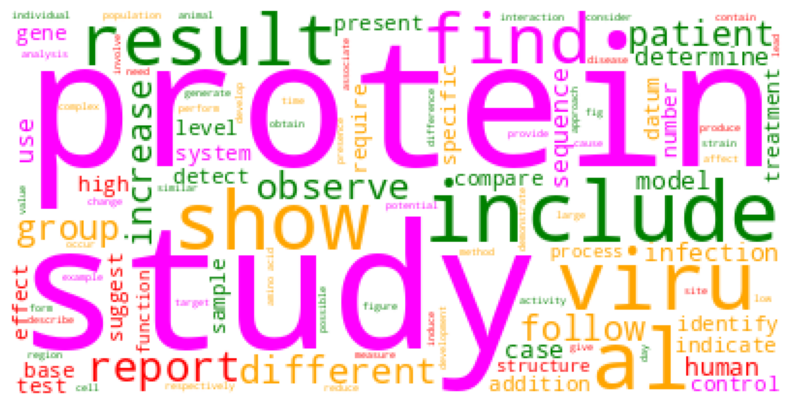

In [106]:
cloud = cloud.generate(corona_df["text"].str.cat(sep = "\n"))
plt.figure(figsize = (10, 10))
plt.imshow(cloud)
plt.axis("off")
plt.show()

In [108]:
corona_df.to_csv("corona_df.csv")

## Extração de entidades nomeadas

### Testes com a função

In [111]:
text = str(corona_df["text"][6205])
print(text)

bottleneck specie prone genetic drift depletion adaptive variation raise probability extinction owe inbreede depression reduce adaptability elucidate mechanism influence adaptive genetic variation differentiation endangered specie informative evolutionary process critical conservation biology major histocompatibility complex mhc essential component vertebrate immune system ideal fitness-relevant marker highly polymorphic genetic region contain multigene family member involve present pathogen-derived peptide t-cell trigger adaptive immune reaction mhc class molecule consist chain associate β2-microglobulin present intracellular antigen cd8 cell mhc class ii molecule consist chain encode separate mhc gene present extracellular pathogen cd4 cell remarkable level polymorphism mhc think sexual selection maternal-fetal interaction pathogen-mediated selection pms demographic process region mhc locus express different expression level find class gene class iiα iiβ gene alternately organize ele

In [120]:
nlp_ent = spacy.load("en_core_web_sm")
nlp_ent.max_length = 2000000

In [121]:
doc = nlp_ent(text)

In [124]:
for entity in doc.ents:
  if entity.label_ == "NORP" or entity.label_ == "GPE":
    print(entity.text, entity.label_)

avian NORP
iib1e2 NORP
china GPE
mendelian NORP
shanghai GPE
china GPE
dbb2 NORP
nini-iiβ NORP
ht01 NORP
cnv GPE
avian NORP
newcastle GPE
nini-iiβ NORP
ht01 NORP
∆k GPE


In [ ]:
from spacy import displacy
displacy.render(doc, style = "ent", jupyter = True)

### Contagem das entidades na base de dados

In [126]:
gpe = []

for index, row in corona_df.iterrows():
  text = row["text"]
  doc = nlp_ent(text)
  for entity in doc.ents:
    if entity.label_ == "GPE":
      gpe.append(str(entity.text))

In [128]:
values_gpe, counts_gpe = np.unique(np.array(gpe), return_counts = True)

In [131]:
gpe_df = pd.DataFrame({"value": values_gpe, "counts": counts_gpe})

In [132]:
gpe_df.head()

,value,counts
0,-(301,1
1,/journal.ppat.1000808.s008,1
2,0.125˚which,1
3,100ng,1
4,120kv,2


In [133]:
gpe_df.shape

(1041, 2)

In [134]:
gpe_df_filteres = gpe_df[gpe_df.counts > 50]

In [135]:
gpe_df_filteres.shape

(20, 2)

In [136]:
gpe_df_filteres

,value,counts
23,al.,896
86,beijing,60
158,china,521
230,egypt,89
260,france,53
273,germany,109
331,hong kong,217
340,hsv-1,64
366,ibv,100
386,india,94


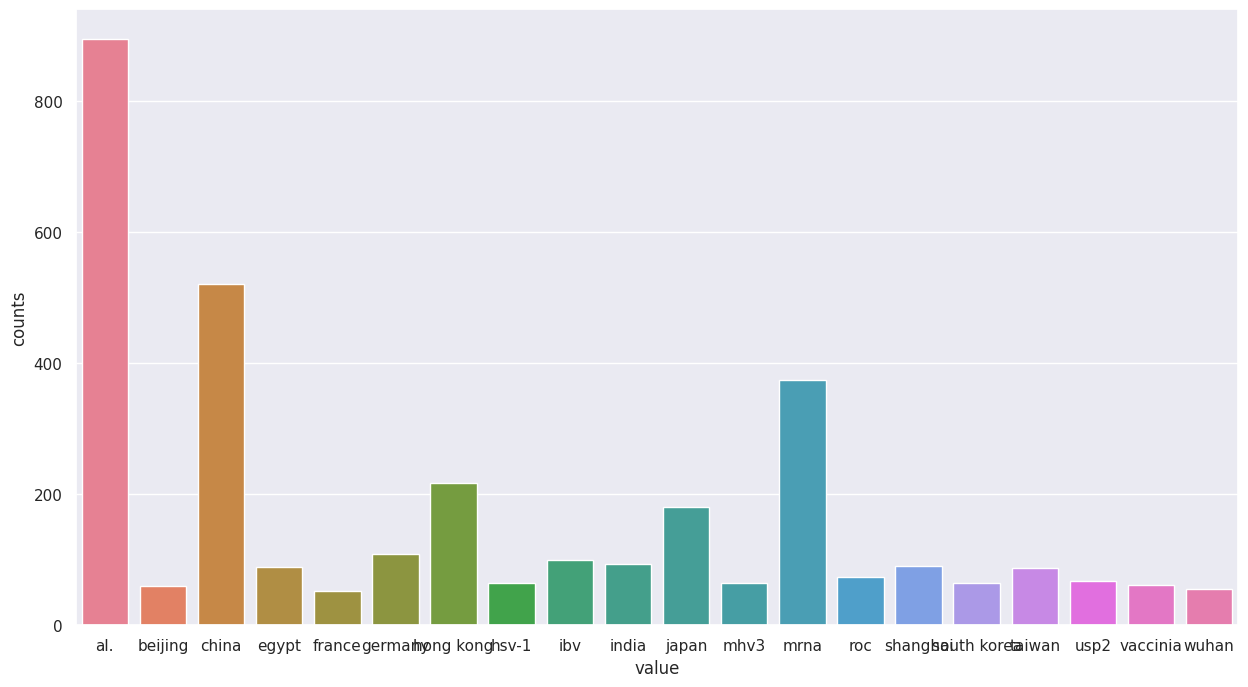

In [141]:
sns.set(rc = {"figure.figsize": (15, 8)})
sns.barplot(x = "value", y = "counts", hue = "value", data = gpe_df_filteres);